In [1]:
import scanpy as sc

In [2]:
import pandas as pd

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [5]:
sc.set_figure_params(dpi=150, dpi_save=300)

In [6]:
adata = sc.read_h5ad( "scvi_output.h5ad") # , backed = 'r' doesnt work if you need to modify a view
adata

AnnData object with n_obs × n_vars = 81812 × 17958
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'lineage', 'fine_celltype', 'broad_celltype', 'cell_to_exclude'
    var: 'highly_variable', 'highly_variable_rank', 'mea

# Plot UMAP

In [7]:
adata.obs['fine_celltype'] = adata.obs['fine_celltype'].str.replace('Mesen_Endo', 'Mesen_')
adata.obs['fine_celltype'] = adata.obs['fine_celltype'].str.replace('Epi_Endo', 'Epi_')


adata.obs['broad_celltype'] = adata.obs['broad_celltype'].str.replace('Mesen_Endo', 'Mesen_')
adata.obs['broad_celltype'] = adata.obs['broad_celltype'].str.replace('Epi_Endo', 'Epi_')

In [8]:
adata.obs['celltype_plotting'] = adata.obs['broad_celltype']
adata = adata[~adata.obs['broad_celltype'].isin(
    [
        'Epi_CervixSquamous',
        'Immune_Myeloid_progenitors',
        'Immune_Erythroid',
        'Immune_Haematopoietic_progenitor_cells',
        'Immune_Megakaryocytes/platelets',
        'Meso_serosa',
])]

adata.obs['celltype_plotting'] = np.where(
    adata.obs['broad_celltype'].str.startswith('Epi_'),
    adata.obs['fine_celltype'],
    adata.obs['celltype_plotting']
)

adata.obs['celltype_plotting'] = np.where(
    adata.obs['celltype_plotting'] ==  'Epi_GlandBas_WIF1', #    'Epi_GlandBas_WIF1', 
    'Epi_GlandBas',
    adata.obs['celltype_plotting']
)


adata.obs['celltype_plotting'] = np.where(
    adata.obs['broad_celltype'] == 'Mesen_StromalFib',
    adata.obs['fine_celltype'],
    adata.obs['celltype_plotting']
)

adata.obs['celltype_plotting'] = np.where(
    adata.obs['broad_celltype'] == 'Mesen_GlandBas',
    adata.obs['fine_celltype'],
    adata.obs['celltype_plotting']
)


/tmp/ipykernel_1205708/3473578093.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['celltype_plotting'] = np.where(


In [9]:
# Count cells per cell type
counts = adata.obs["celltype_plotting"].value_counts()

# Keep only cell types with >= 50 cells (otherwise legend is confusing & misleading)
keep_types = counts[counts >= 50].index

# Subset AnnData
adata = adata[adata.obs["celltype_plotting"].isin(keep_types)].copy()

In [10]:

category_order = [
    # EPITHELIAL
    'Epi_Cil_Cyc', 
    'Epi_Cil_Diff', 
    'Epi_Cil_eProf',


    'Epi_GlandFun_Menstr', 
    'Epi_GlandFun_Prof', 
    'Epi_GlandFun_Prof_Cyc', 
    'Epi_GlandFun_emSec', 
    'Epi_GlandFun_lProf', 
    'Epi_GlandFun_mSec',
    'Epi_GlandFun_lSec', 

    'Epi_GlandLum_Prof', 
    'Epi_GlandLum_eSec',
   'Epi_GlandLum_mSec', 

   'Epi_Gland_nEMC', 
   'Epi_Mucinous', 
   'Epi_GlandBas', 

    # MESENCHYMAL — FIBROBLASTS
    'Mesen_AdvFibs', 
    'Mesen_AdvFibsIntr', 

    'Mesen_GlandBas',
    'Mesen_StromalFib_Prolif', 
    'Mesen_StromalFib_Prolif_Cyc',
    'Mesen_StromalFib_eSec', 
    'Mesen_StromalFib_mSec', 
    'Mesen_StromalFib_lSec', 

    'Mesen_StromalFib_nEMC', 
    'Mesen_StromalFib_nEMC_Cyc',
    'Mesen_StromalFib_nEMC_Sec',
    'Mesen_StromalFib_Menopause',

    'Mesen_StromalFib_MenstrualEutopic',
    'Mesen_StromalFib_MenstrualFluid',

    # MESENCHYMAL — OTHER
    'Mesen_Pericyte',
    'Mesen_SMCs', 
    'Mesen_vSMCs',

    # ENDOTHELIAL
    "Endo_artery",
    "Endo_cap",
    "Endo_lymp",
    "Endo_ven",

    # IMMUNE
    'Immune_B_cells',
    'Immune_Conventional_DC',
   # 'Immune_Erythroid',
    'Immune_Granulocytes',
   # 'Immune_Haematopoietic_progenitor_cells',
     'Immune_ILC',
     'Immune_Macrophages',
    # 'Immune_Megakaryocytes/platelets',
     'Immune_Monocytes',
    # 'Immune_Myeloid_progenitors',
     'Immune_NK_cells',
     'Immune_Non-conventional_DC',
     'Immune_T_cells',

    # Neural
    'Neural_Schwann'
]


In [11]:
adata.obs['celltype_plotting'].nunique()

16

In [12]:
set(adata.obs['celltype_plotting'].unique()) - set(category_order)

set()

In [13]:
adata.obs['celltype_plotting'] = pd.Categorical(
    adata.obs['celltype_plotting'], 
    categories = category_order, 
    ordered = True
)

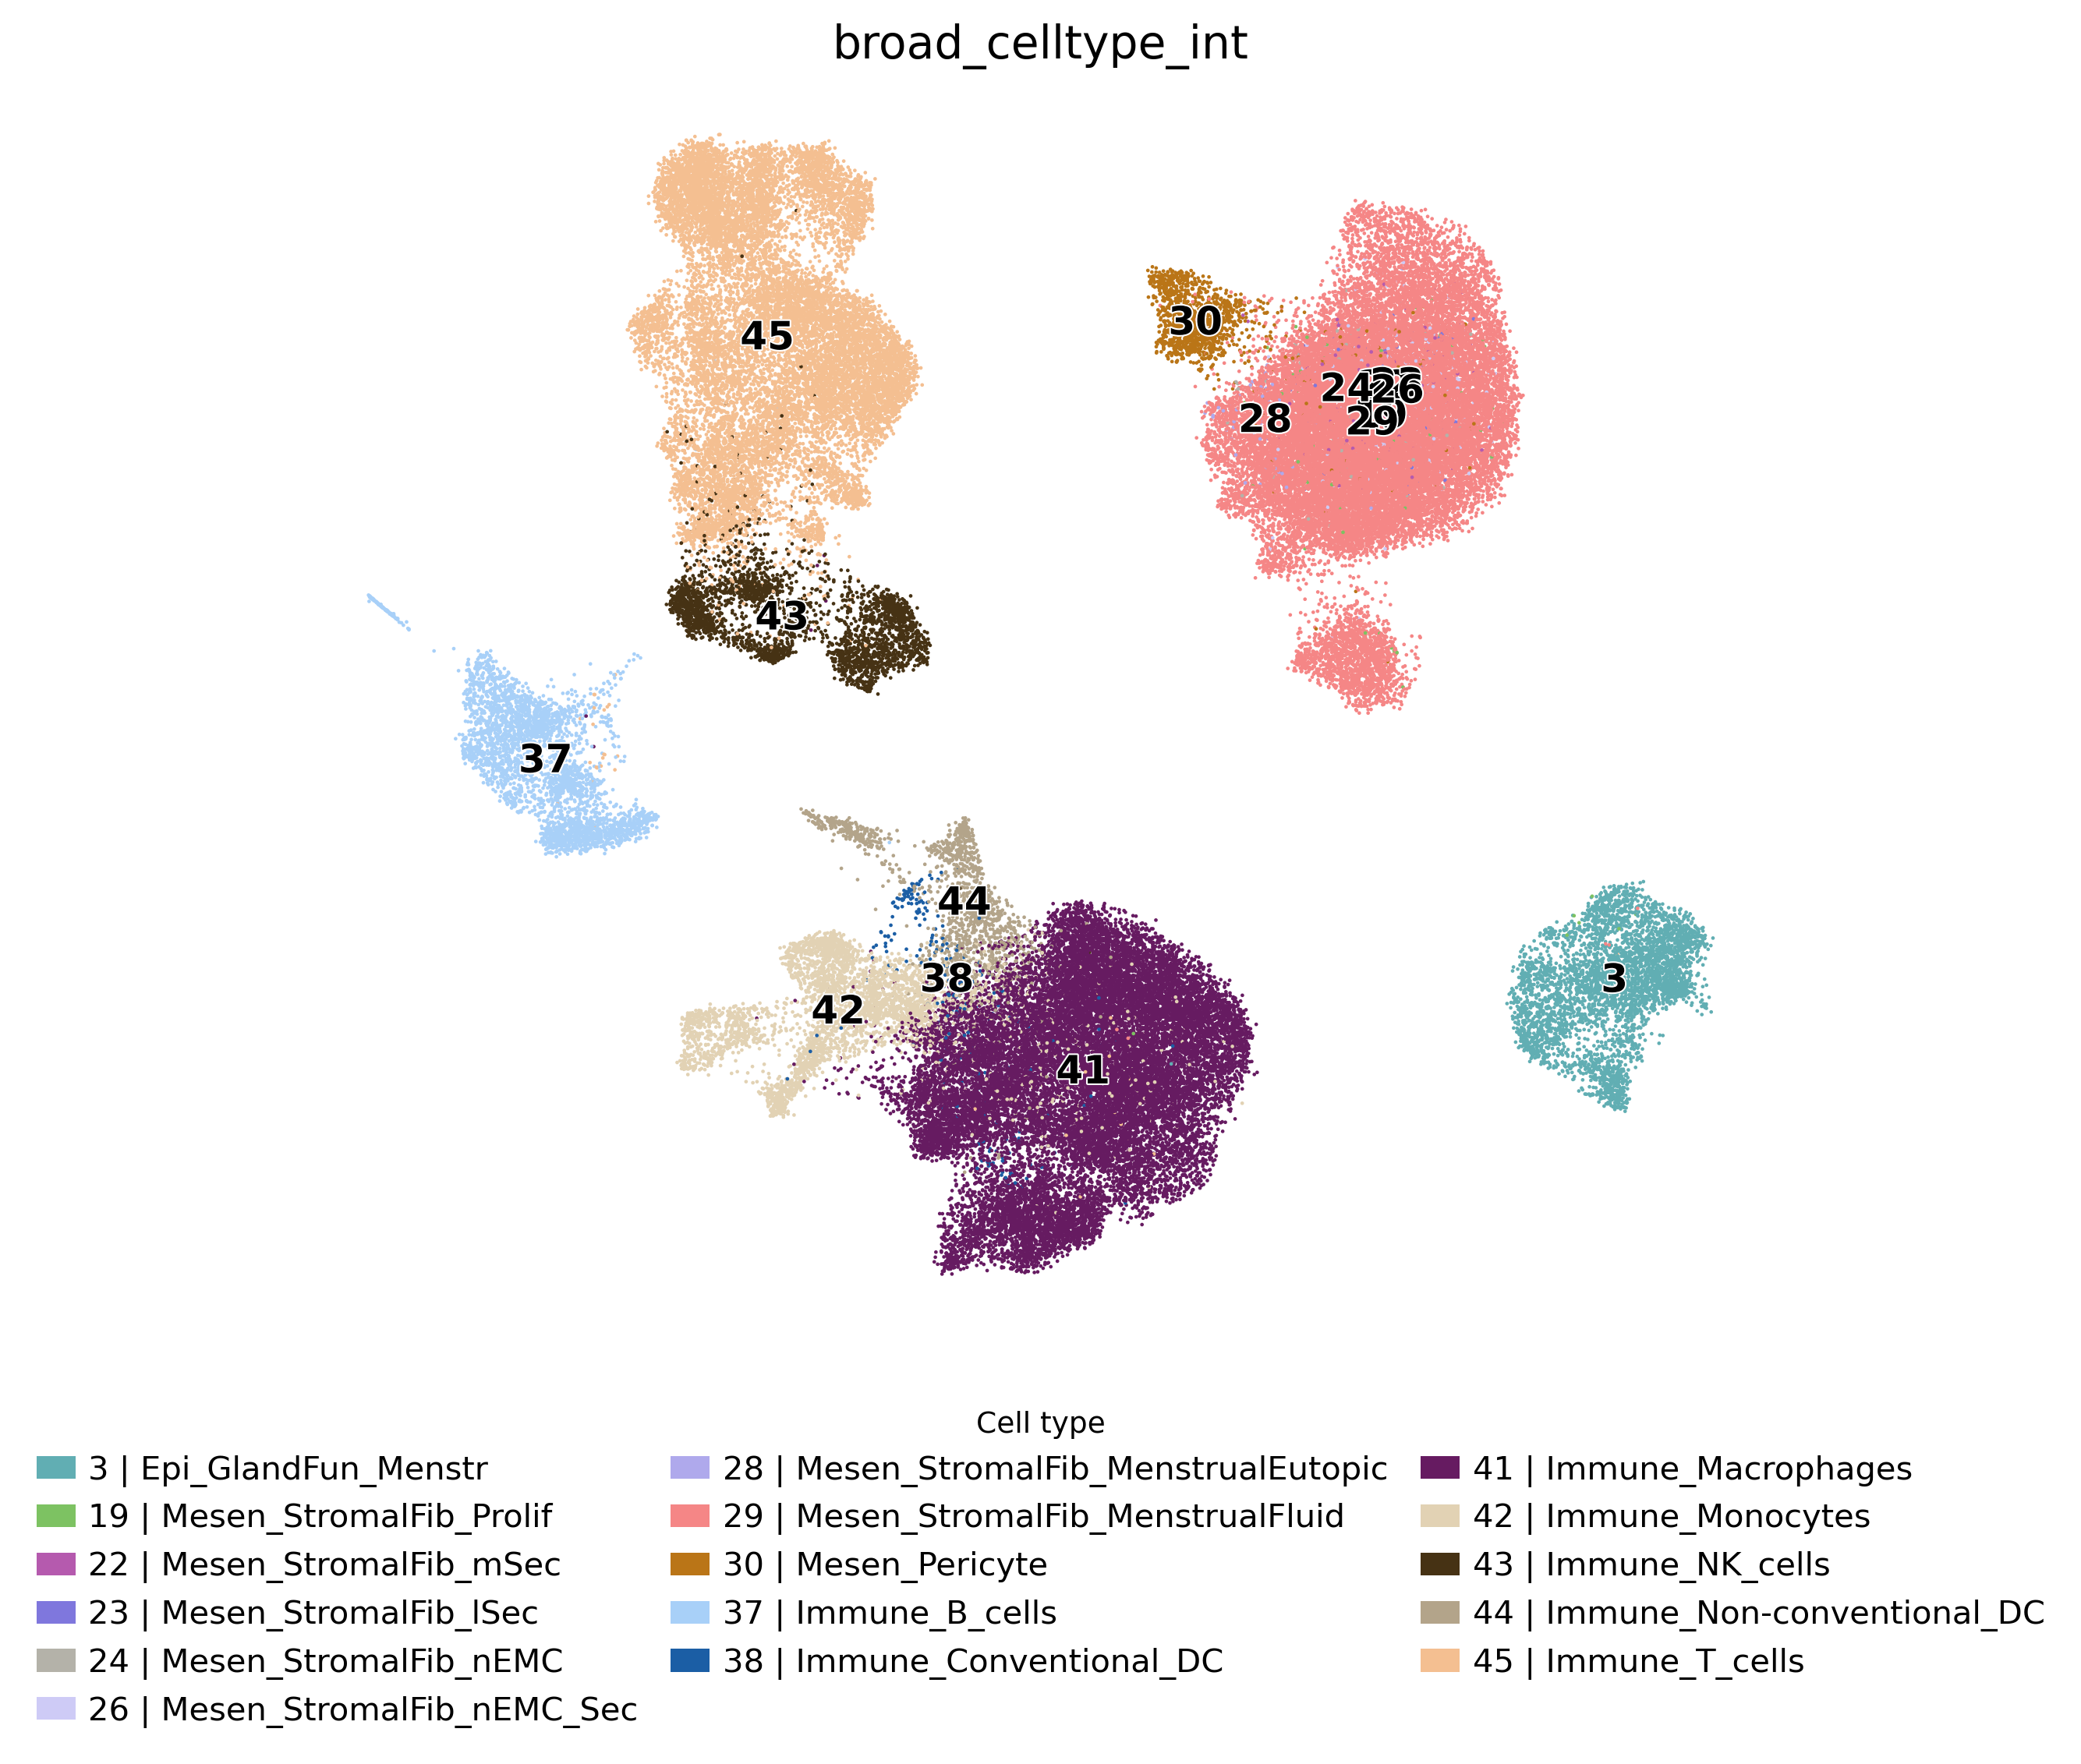

In [14]:

new_colors = [
    "#D85A30",
    "#F0997B",
    "#EF9F27",
    "#61aeb3",
    "#faed89",
    "#5aab3e",
    "#e24b4a",
    "#c76bbc",
    "#a94d8b",
    "#ab9d45",
    "#d4c34e",
    "#c4e0ff",
    "#7cc8eb",
    "#143f70",
    "#5dabff",
    "#396696",
    "#3d82cc",
    "#7dc262",
    "#eca9e8",
    "#e69ddd",
    "#b55aae",
    "#7F77DD",
    "#B4B2A9",
    "#97C459",
    "#CECBF6",
    "#378ADD",
    "#AFA9EC",
    "#f58686",
    "#BA7517",
    "#888780",
    "#1D9E75",
    "#D4537E",
    "#f5b8b8",
    "#ED93B1",
    "#e6a433",
    "#a8d0f8",
    "#1b5ea5",
    "#3d8a28",
    "#c23535",
    "#661b61",
    "#e2d2b4",
    "#463214",
    "#b3a48a",
    "#f4bf91",
    "#9b4595",
    "#e012b7",
    "#b9a429",
    "#143f70",
    "#fbcaf7",
    "#a9a5a5",
    "#9FE1CB"
]

# specifically for glandular positions
epi_index = category_order.index('Epi_GlandBas')
new_colors.insert(epi_index, "#013220",)  

mesen_index = category_order.index('Mesen_GlandBas')
new_colors.insert(mesen_index, "#000000",)


# -----------------------------
# Settings
# -----------------------------
celltype_col = "celltype_plotting"
int_col = "broad_celltype_int"

# Cell types to draw on top, without changing color/category order
top_celltypes = ["Epi_GlandBas", "Mesen_GlandBas"]  # <-- edit these

# -----------------------------
# Set categorical order
# -----------------------------
adata.obs[celltype_col] = pd.Categorical(
    adata.obs[celltype_col],
    categories=category_order,
    ordered=True
)

# -----------------------------
# Create integer categories
# -----------------------------
cats = list(adata.obs[celltype_col].cat.categories)

cat_to_int = {cat: i for i, cat in enumerate(cats)}
int_to_cat = {i: cat for cat, i in cat_to_int.items()}

adata.obs[int_col] = pd.Categorical(
    adata.obs[celltype_col].map(cat_to_int),
    categories=list(range(len(cats))),
)

# Important: colors must match integer category order
adata.uns[f"{int_col}_colors"] = new_colors

# -----------------------------
# Put selected cell types on top
# -----------------------------
plot_order = adata.obs[celltype_col].isin(top_celltypes)

adata_plot = adata[np.argsort(plot_order.values)].copy()

# Re-apply explicit categories after copy (AnnData strips unused ones)
adata_plot.obs[int_col] = pd.Categorical(
    adata_plot.obs[int_col],
    categories=list(range(len(cats))),
)
adata_plot.uns[f"{int_col}_colors"] = adata.uns[f"{int_col}_colors"]

# -----------------------------
# Match UMAP aspect ratio
# -----------------------------
xy = adata.obsm["X_umap"]
umap_ratio = np.ptp(xy[:, 0]) / np.ptp(xy[:, 1])

fig_h = 8
fig_w = fig_h * umap_ratio

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# -----------------------------
# Plot UMAP
# -----------------------------
sc.pl.umap(
    adata_plot,
    color=int_col,
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=1,
    size=5,
    frameon=False,
    ax=ax,
    show=False,
)

# -----------------------------
# Rasterize ONLY the points
# -----------------------------
for coll in ax.collections:
    coll.set_rasterized(True)

ax.set_aspect("equal", adjustable="box")

# -----------------------------
# External legend: only show used categories, keep original ints/order
# -----------------------------
colors = adata.uns[f"{int_col}_colors"]

used_ints = (
    adata.obs[int_col]
    .dropna()
    .astype(int)
    .unique()
)

used_ints = sorted(used_ints)

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor="none",
        label=f"{i} | {int_to_cat[i]}"
    )
    for i in used_ints
]

ax.legend(
    handles=handles,
    title="Cell type",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=10,
    title_fontsize=9,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.95,
    bottom=0.28
)

plt.savefig(
    "umap_flex.pdf",
    bbox_inches="tight",
     dpi=600,
)

plt.show()

In [15]:
adata.obs['celltype_plotting'].value_counts()

celltype_plotting
Mesen_StromalFib_MenstrualFluid      26953
Immune_Macrophages                   21597
Immune_T_cells                       15110
Epi_GlandFun_Menstr                   4122
Immune_Monocytes                      3843
Immune_B_cells                        3355
Immune_NK_cells                       2851
Immune_Non-conventional_DC            1450
Mesen_Pericyte                        1284
Mesen_StromalFib_nEMC_Sec              272
Immune_Conventional_DC                 271
Mesen_StromalFib_mSec                  146
Mesen_StromalFib_Prolif                 94
Mesen_StromalFib_lSec                   90
Mesen_StromalFib_nEMC                   79
Mesen_StromalFib_MenstrualEutopic       56
Epi_Gland_nEMC                           0
Epi_Mucinous                             0
Epi_GlandLum_eSec                        0
Epi_GlandLum_Prof                        0
Epi_GlandFun_lSec                        0
Epi_GlandLum_mSec                        0
Epi_GlandFun_lProf                  

# Endometrial identity

In [16]:
adata.X.max()

np.int64(19353)

In [17]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

In [18]:
 adata.obs['broad_celltype'].value_counts()

broad_celltype
Mesen_StromalFib              27690
Immune_Macrophages            21597
Immune_T_cells                15110
Epi_GlandFun                   4122
Immune_Monocytes               3843
Immune_B_cells                 3355
Immune_NK_cells                2851
Immune_Non-conventional_DC     1450
Mesen_Pericyte                 1284
Immune_Conventional_DC          271
Name: count, dtype: int64

/software/cellgen/team361/mm58/envs/singlecellatlas/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team361/mm58/envs/singlecellatlas/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/tmp/ipykernel_1205708/2889623433.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


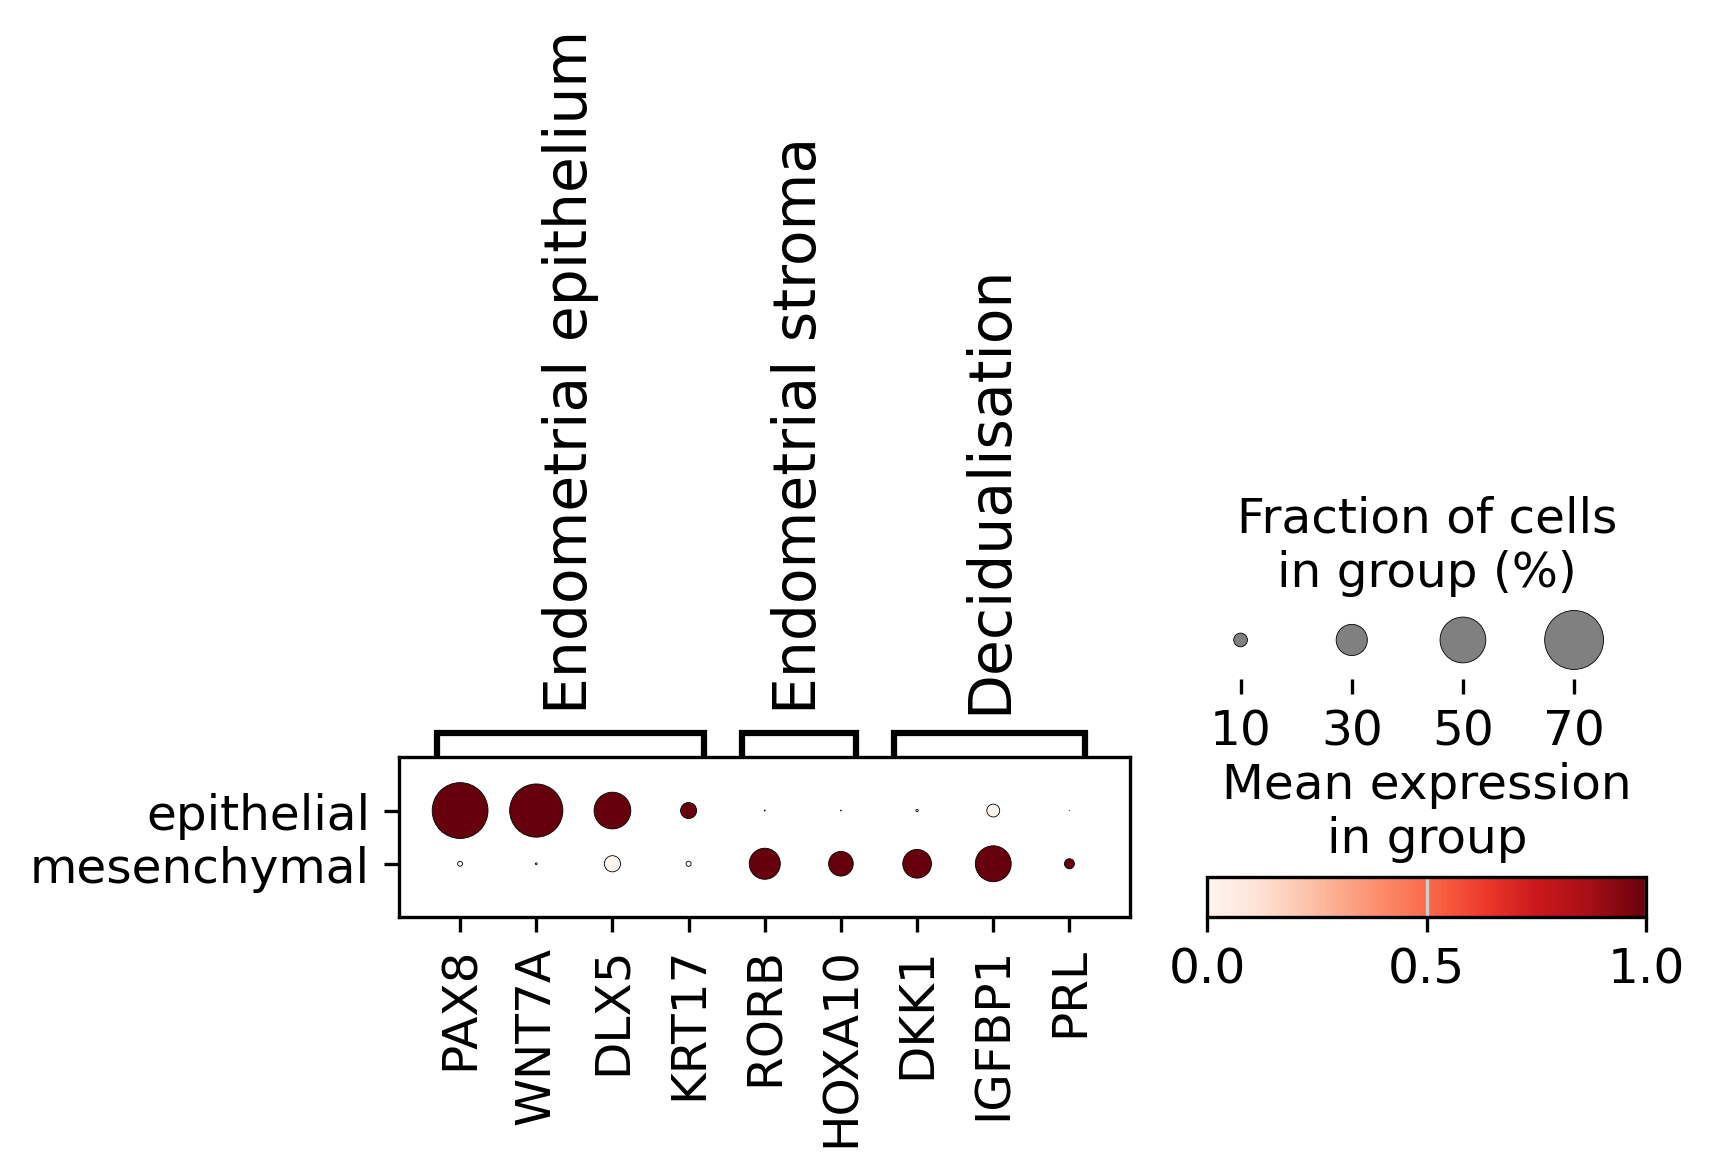

In [23]:
sc.pl.dotplot(
    adata[adata.obs['broad_celltype'].isin(['Mesen_StromalFib', 'Epi_GlandFun'])],
    {
        'Endometrial epithelium' : ['PAX8', 'WNT7A', 'DLX5', 'KRT17'],
        'Endometrial stroma' : ['RORB', 'HOXA10'], 
        'Decidualisation' : ['DKK1', 'IGFBP1',  'PRL'] # 'SCARA5',
    },
    groupby = 'lineage', 
    standard_scale = 'var',
    save = 'flex_markers.pdf'
)

In [20]:
adata.obs['lineage'].value_counts()

lineage
immune         48477
mesenchymal    28974
epithelial      4122
Name: count, dtype: int64